<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/Aula_6_TransferLearning_Flores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning na Prática — Caso BotaniBR

### FIAP · MBA Data Science & Inteligência Artificial · Deep Learning

---

## O caso

A **BotaniBR** é um marketplace B2B que conecta produtores de flores a floristas em todo o Brasil. Todo dia, **mais de 50 mil imagens** chegam dos fornecedores para serem listadas no catálogo. Hoje, a categorização é manual: gera filas de aprovação de até 8h, erros de etiqueta e clientes recebendo o produto errado.

A pergunta de negócio que vamos atacar:

> *É possível treinar um classificador de flores que aprenda com poucos dados, em poucas horas, e libere o time para tarefas de maior valor?*

Para o nosso piloto, restringimos o catálogo a **5 espécies-piloto** — daisy (margarida), dandelion (dente-de-leão), roses (rosas), sunflowers (girassóis) e tulips (tulipas) — usando o dataset `tf_flowers`, que contém ~3.670 imagens reais.

---

## O que você vai aprender

1. Por que **reaproveitar conhecimento** é mais eficaz que treinar do zero
2. Como montar um **pipeline `tf.data`** com data augmentation
3. Como treinar um **baseline CNN** (referência de comparação)
4. **Feature Extraction**: backbone congelado + cabeça customizada
5. **Fine-Tuning**: liberar últimas camadas com learning rate reduzido
6. Como **avaliar e comparar** modelos com curvas, matriz de confusão e análise de erros
7. Quando aplicar cada estratégia no mundo real


---
## Etapa 1 — Setup do ambiente

Importações, fixação de seeds e checagem de GPU. Se estiver no Colab, garanta que o runtime esteja em GPU (`Runtime > Change runtime type > T4 GPU`).


In [1]:
# --- imports principais ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import tensorflow_datasets as tfds
from sklearn.metrics import confusion_matrix, classification_report

# --- reprodutibilidade ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- estilo dos plots ---
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

print(f"TensorFlow ............ {tf.__version__}")
print(f"GPU disponível ........ {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Devices ............... {[d.name for d in tf.config.list_physical_devices()]}")


TensorFlow ............ 2.19.0
GPU disponível ........ True
Devices ............... ['/physical_device:CPU:0', '/physical_device:GPU:0']


---
## Etapa 2 — Carregando o dataset `tf_flowers`

O `tf_flowers` é um dataset clássico mantido pelo time do TensorFlow:

| Atributo | Valor |
|---|---|
| Número de imagens | 3.670 |
| Classes | 5 (daisy, dandelion, roses, sunflowers, tulips) |
| Resolução | variável (vamos redimensionar para 224×224) |
| Origem | Imagens reais coletadas na natureza |

Vamos carregar via `tensorflow_datasets` e dividir 80% treino / 20% validação. O TFDS já cuida do download e cache local, então só roda devagar na primeira execução.


In [2]:
# --- download e split ---
(ds_train, ds_val), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,    # retorna tuplas (image, label) em vez de dicts
    with_info=True,
    shuffle_files=True,
)

NUM_CLASSES = ds_info.features['label'].num_classes
CLASS_NAMES = ds_info.features['label'].names
TOTAL_TRAIN = ds_info.splits['train'].num_examples

print(f"Total de imagens .... {TOTAL_TRAIN}")
print(f"Número de classes ... {NUM_CLASSES}")
print(f"Classes ............. {CLASS_NAMES}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.EVZ4QW_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Total de imagens .... 3670
Número de classes ... 5
Classes ............. ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


### Distribuição das classes

Antes de treinar, é fundamental saber se temos **classes balanceadas**. Desbalanceamento severo exigiria estratégias específicas (ex: class weights, oversampling) — assunto de outras aulas de Feature Engineering.


    classe  imagens  proporcao_%
 dandelion      898         24.5
     daisy      633         17.2
    tulips      799         21.8
sunflowers      699         19.0
     roses      641         17.5


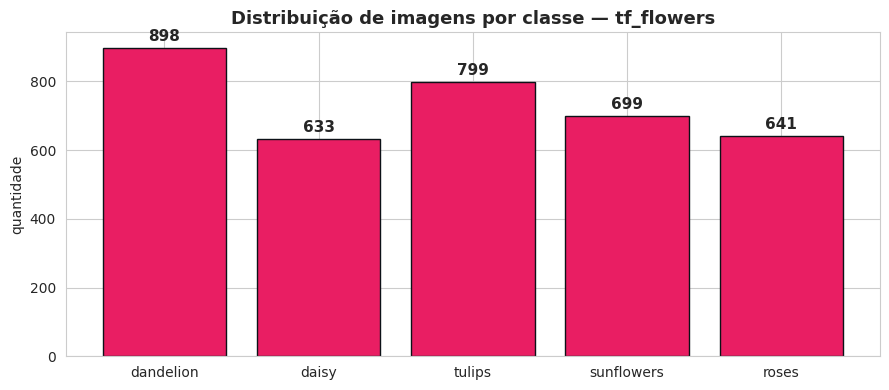

In [3]:
# --- contagem por classe ---
counts = np.zeros(NUM_CLASSES, dtype=int)
for _, label in tfds.load('tf_flowers', split='train', as_supervised=True):
    counts[label.numpy()] += 1

dist_df = pd.DataFrame({'classe': CLASS_NAMES, 'imagens': counts})
dist_df['proporcao_%'] = (dist_df['imagens'] / dist_df['imagens'].sum() * 100).round(1)
print(dist_df.to_string(index=False))

# --- visualização ---
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASS_NAMES, counts, color='#E91E63', edgecolor='#0D1117')
ax.set_title('Distribuição de imagens por classe — tf_flowers',
             fontsize=13, fontweight='bold')
ax.set_ylabel('quantidade')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(c), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Leitura:** o dataset é razoavelmente balanceado, com cada classe representando entre ~17% e ~25% do total. Não precisamos aplicar técnicas de balanceamento para essa demonstração.

### Visualizando amostras

Antes de qualquer modelo, sempre olhe os dados. Veja como cada classe se apresenta — variações de ângulo, iluminação, fundo e zoom são exatamente o tipo de ruído que o modelo precisará lidar em produção.


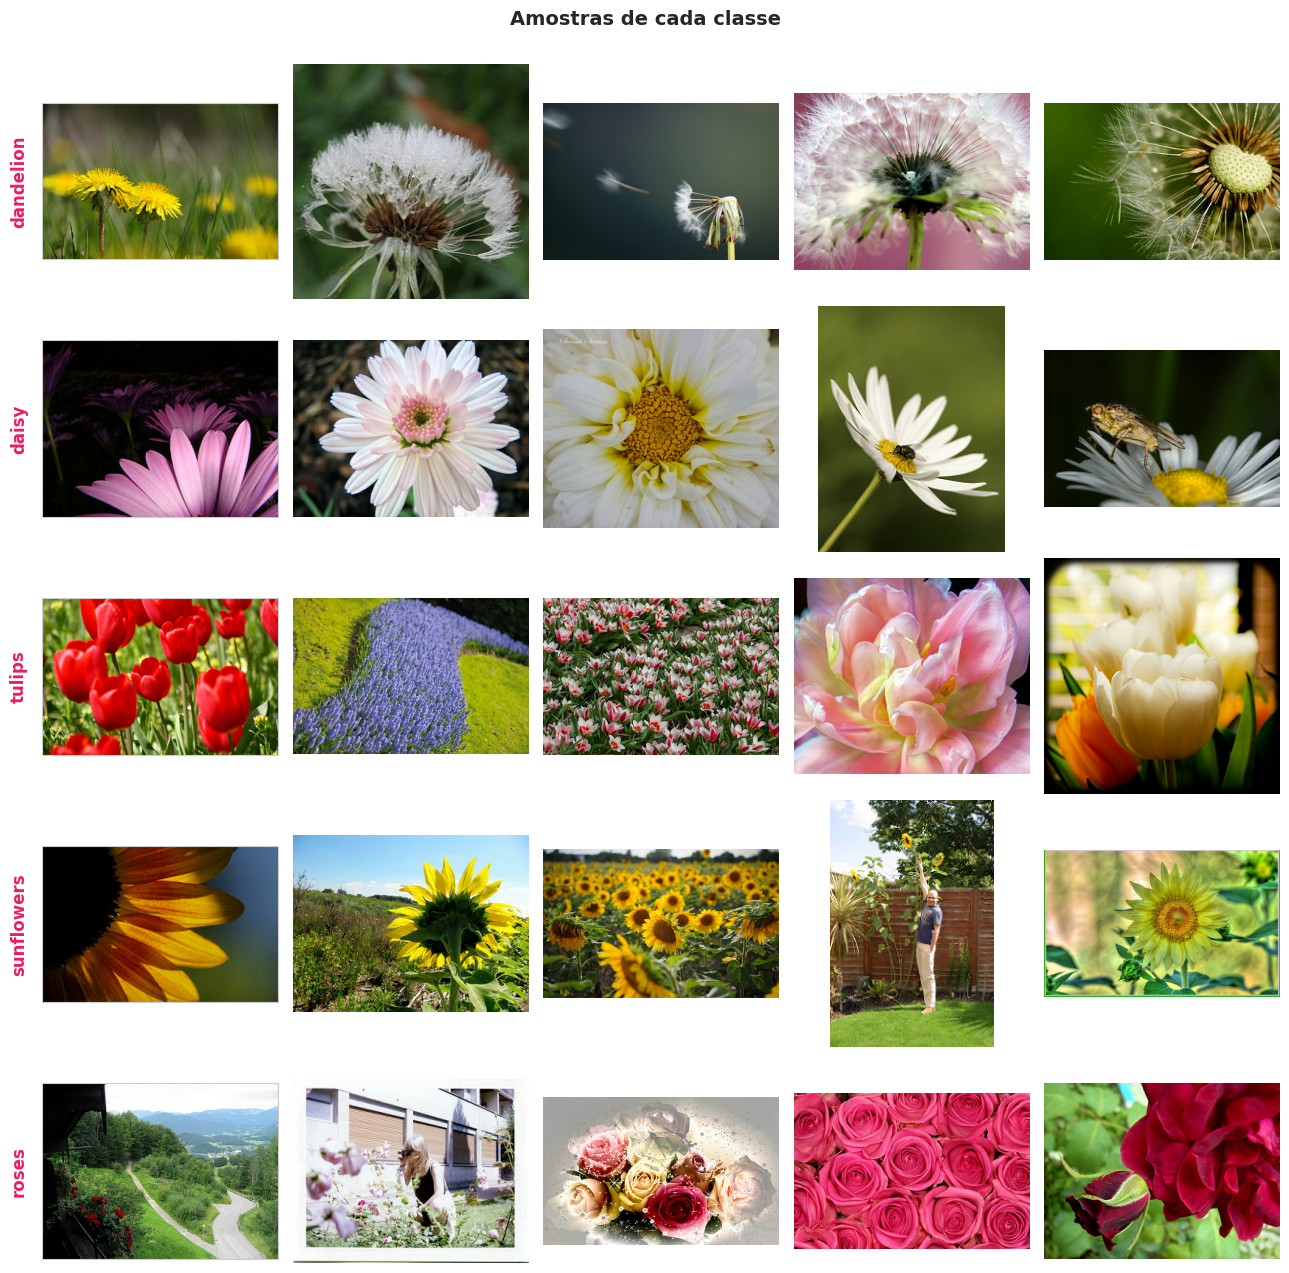

In [4]:
# --- 5 amostras de cada classe (uma linha por classe) ---
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(13, 13))
samples_per_class = {i: [] for i in range(NUM_CLASSES)}

for img, label in tfds.load('tf_flowers', split='train', as_supervised=True).take(500):
    lbl = label.numpy()
    if len(samples_per_class[lbl]) < 5:
        samples_per_class[lbl].append(img.numpy())
    if all(len(v) >= 5 for v in samples_per_class.values()):
        break

for i in range(NUM_CLASSES):
    for j in range(5):
        ax = axes[i, j]
        ax.imshow(samples_per_class[i][j])
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[i], rotation=90, fontsize=12,
                          fontweight='bold', color='#E91E63', labelpad=10)
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle('Amostras de cada classe', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


---
## Etapa 3 — Pipeline `tf.data`

O `tf.data` é o jeito eficiente de alimentar a rede. Vamos:

1. **Resize** — toda imagem para 224×224 (input padrão do EfficientNetB0)
2. **Cache** — guardar em memória depois do primeiro acesso
3. **Shuffle** — embaralhar a cada época (só no treino)
4. **Batch** — agrupar em lotes de 32
5. **Prefetch** — preparar o próximo batch enquanto a GPU treina o atual

> **Importante sobre normalização:** o `EfficientNetB0` da Keras tem uma camada `Normalization` interna e espera **inputs no range [0, 255]**. Por isso **não dividimos por 255** aqui. Para o nosso baseline CNN do zero, vamos colocar uma `Rescaling(1./255)` como primeira camada do modelo.


In [5]:
# --- hiperparâmetros do pipeline ---
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# --- função de pré-processamento (necessária para tf.data.map) ---
def resize_and_cast(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)   # mantém range [0, 255]
    return image, label

# --- pipeline de treino ---
ds_train_prepared = (
    ds_train
    .map(resize_and_cast, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# --- pipeline de validação (sem shuffle) ---
ds_val_prepared = (
    ds_val
    .map(resize_and_cast, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# --- inspecionar shapes ---
for images, labels in ds_train_prepared.take(1):
    print(f"Batch de imagens: shape={images.shape}, dtype={images.dtype}")
    print(f"Batch de labels:  shape={labels.shape}, dtype={labels.dtype}")
    print(f"Range dos pixels: [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")


Batch de imagens: shape=(32, 224, 224, 3), dtype=<dtype: 'float32'>
Batch de labels:  shape=(32,), dtype=<dtype: 'int64'>
Range dos pixels: [0.0, 255.0]


### Data Augmentation

Augmentation cria variações **artificiais** das imagens de treino — flips, rotações, zooms — fazendo o modelo enxergar muito mais "casos" sem precisarmos coletar mais dados.

⚠️ **Regra de ouro:** augmentation **só no treino**, nunca na validação. A validação tem que parecer com o mundo real (fotos cruas como na BotaniBR), senão a métrica vira viés a favor do modelo.

Vamos definir augmentation como um `Sequential` de layers, que será embutido no modelo. Na inferência (`model.predict()`), essas layers são automaticamente desligadas pelo Keras.


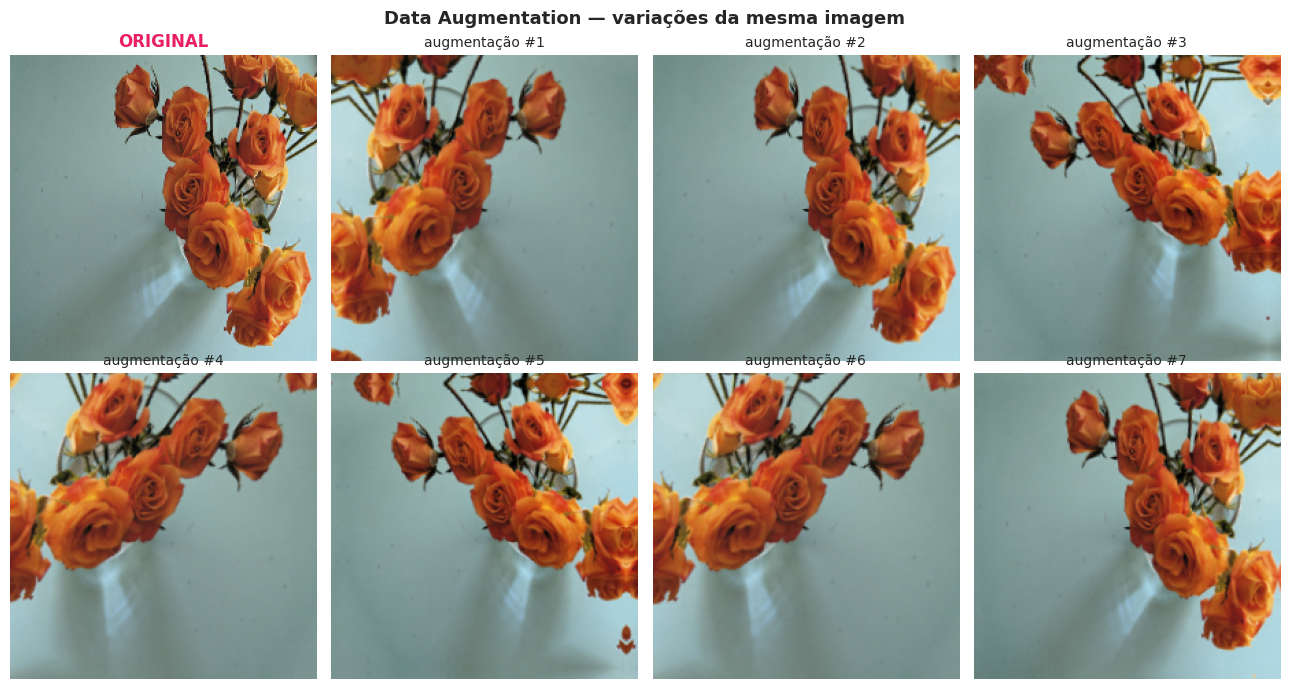

In [6]:
# --- bloco de data augmentation ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
    layers.RandomContrast(0.1, seed=SEED),
], name="data_augmentation")

# --- visualizar o efeito numa imagem ---
sample_batch = next(iter(ds_train_prepared))
sample_img = sample_batch[0][0:1]   # primeira imagem do primeiro batch

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
axes[0, 0].imshow(sample_img[0].numpy().astype('uint8'))
axes[0, 0].set_title('ORIGINAL', fontweight='bold', color='#E91E63')
axes[0, 0].axis('off')

# 7 versões aumentadas
for i, ax in enumerate(axes.flat[1:]):
    augmented = data_augmentation(sample_img, training=True)
    ax.imshow(augmented[0].numpy().astype('uint8'))
    ax.set_title(f'augmentação #{i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Data Augmentation — variações da mesma imagem',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Etapa 4 — Baseline: CNN treinada do zero

Antes de partir para Transfer Learning, vamos treinar uma CNN simples **do zero** para termos uma **referência de comparação**. Sem baseline, não sabemos se o ganho do TL veio do modelo pré-treinado ou se qualquer rede resolveria o problema.

### Arquitetura
- 3 blocos `Conv2D + BatchNorm + MaxPool`
- `GlobalAveragePooling2D` (em vez de Flatten — menos parâmetros)
- `Dense(64) + Dropout(0.5)`
- `Dense(5, softmax)` para as classes
- `Rescaling(1./255)` como primeira layer (normalização)

> Esta é uma rede **propositalmente modesta**. O objetivo é mostrar a dificuldade de aprender com poucos dados quando começamos do zero.


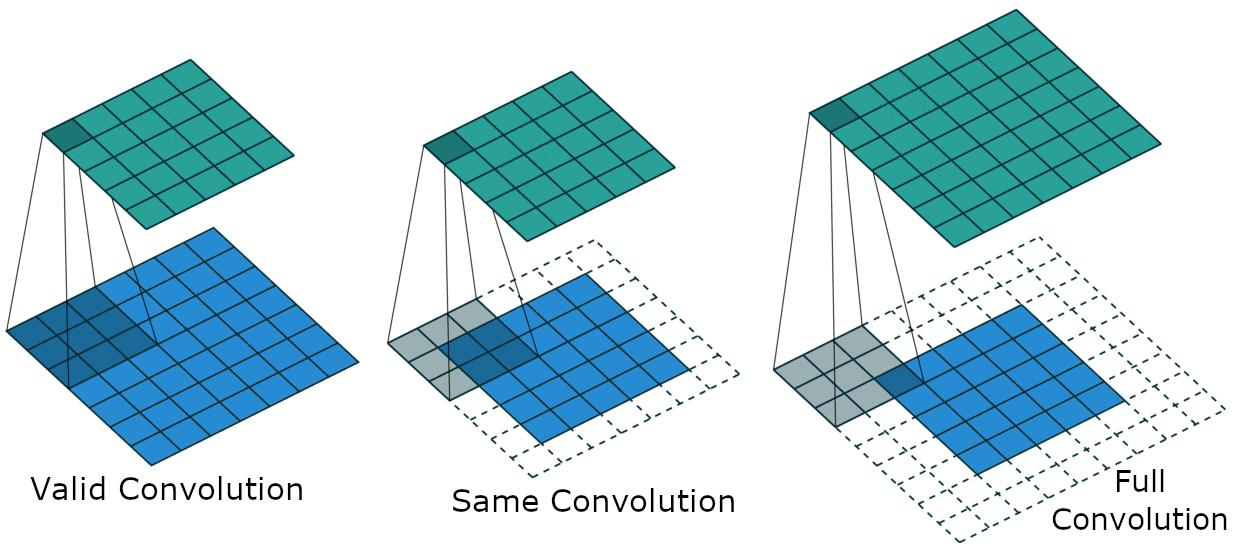

In [7]:
# --- arquitetura do baseline ---
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 1) data augmentation (só ativa no treino)
x = data_augmentation(inputs)

# 2) normalização
x = layers.Rescaling(1./255)(x)

# 3) bloco 1
x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# 4) bloco 2
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# 5) bloco 3
x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# 6) cabeça de classificação
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

baseline_model = keras.Model(inputs, outputs, name='baseline_cnn')

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,725 (401.27 KB)

 Trainable params: 102,277 (399.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# --- treinar baseline ---
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, mode='max',
    restore_best_weights=True, verbose=1
)

history_baseline = baseline_model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 144ms/step - accuracy: 0.4680 - loss: 1.3036 - val_accuracy: 0.2248 - val_loss: 1.6873
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.5521 - loss: 1.1328 - val_accuracy: 0.2262 - val_loss: 1.9582
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.5651 - loss: 1.0748 - val_accuracy: 0.2425 - val_loss: 2.0264
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.5920 - loss: 1.0235 - val_accuracy: 0.2766 - val_loss: 1.8069
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.6161 - loss: 0.9946 - val_accuracy: 0.3488 - val_loss: 1.6581
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.6431 - loss: 0.9256 - val_accuracy: 0.4401 - val_loss: 1.5151
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.6618 - loss: 0.8952 - val_accuracy: 0.5899 - val_loss: 1.0317
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.6642 - loss: 0.8786 - val_accu

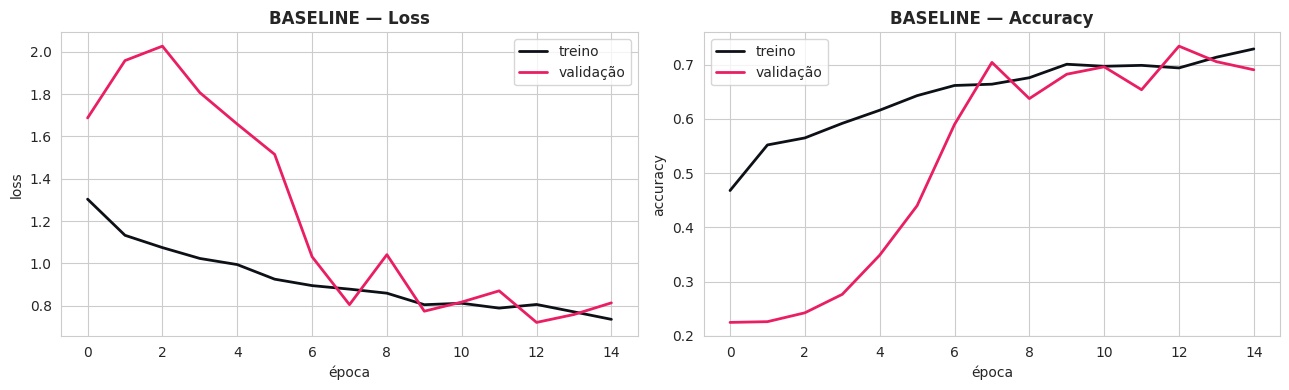


>> Melhor val_accuracy do baseline: 0.7343


In [9]:
# --- curvas do baseline ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_baseline.history['loss'], label='treino', color='#0D1117', lw=2)
axes[0].plot(history_baseline.history['val_loss'], label='validação', color='#E91E63', lw=2)
axes[0].set_title('BASELINE — Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('época'); axes[0].set_ylabel('loss'); axes[0].legend()

axes[1].plot(history_baseline.history['accuracy'], label='treino', color='#0D1117', lw=2)
axes[1].plot(history_baseline.history['val_accuracy'], label='validação', color='#E91E63', lw=2)
axes[1].set_title('BASELINE — Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('época'); axes[1].set_ylabel('accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

baseline_val_acc = max(history_baseline.history['val_accuracy'])
print(f"\n>> Melhor val_accuracy do baseline: {baseline_val_acc:.4f}")


**Leitura típica do baseline:** acurácia de validação na faixa de 60-72% (varia entre execuções por causa do shuffle). Note como train_acc cresce mais rápido que val_acc — sinal clássico de **overfitting** quando o dataset é pequeno e o modelo precisa aprender tudo do zero.

Vamos ver se Transfer Learning faz melhor.


---
## Etapa 5 — Fase 1: Feature Extraction com EfficientNetB0

Agora vem o coração da aula. Vamos:

1. Carregar `EfficientNetB0` com pesos do **ImageNet** (~14M imagens, 1.000 classes)
2. **Congelar** todo o backbone (`trainable = False`) — ele só extrai features
3. Plugar uma **cabeça nova** (GlobalAvgPool + Dropout + Dense) para nossas 5 classes
4. Treinar **só a cabeça** — rapidíssimo

### Por que EfficientNetB0?
| Atributo | Valor |
|---|---|
| Parâmetros | 5,3M (vs. 25M do ResNet50) |
| Top-1 ImageNet | 77,1% |
| Input | 224×224×3 |
| Compound scaling | Balanceia profundidade × largura × resolução |

É o sweet spot entre acurácia e custo computacional para o nosso caso.


In [10]:
# --- carregar backbone pré-treinado ---
base_model = EfficientNetB0(
    include_top=False,            # remove a cabeça original (1.000 classes ImageNet)
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# --- congelar o backbone ---
base_model.trainable = False

print(f"Camadas no backbone: {len(base_model.layers)}")
print(f"Backbone treinável?  {base_model.trainable}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Camadas no backbone: 238
Backbone treinável?  False


In [11]:
# --- montar modelo completo: augmentation -> backbone -> cabeça ---
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# augmentation (só no treino, automaticamente)
x = data_augmentation(inputs)

# backbone (congelado, training=False mantém BN em modo inferência)
x = base_model(x, training=False)

# cabeça customizada
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='efficientnet_feature_extraction')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()


Model: "efficientnet_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**Observação importante na summary:** veja como `Trainable params` é dramaticamente menor que `Total params`. Estamos treinando só a cabeça (~6 mil parâmetros), enquanto os ~5,3 milhões do backbone ficam congelados. Por isso o treino é tão rápido.


In [12]:
# --- treinar Fase 1 (Feature Extraction) ---
early_stop_p1 = EarlyStopping(
    monitor='val_accuracy', patience=4, mode='max',
    restore_best_weights=True, verbose=1
)

history_p1 = tl_model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=12,
    callbacks=[early_stop_p1],
    verbose=1
)


Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.6941 - loss: 0.8605 - val_accuracy: 0.8733 - val_loss: 0.4385
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.8525 - loss: 0.4563 - val_accuracy: 0.9046 - val_loss: 0.3151
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.8801 - loss: 0.3668 - val_accuracy: 0.9114 - val_loss: 0.2726
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.8869 - loss: 0.3247 - val_accuracy: 0.9128 - val_loss: 0.2448
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9022 - loss: 0.2889 - val_accuracy: 0.9210 - val_loss: 0.2249
Epoch 6/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9111 - loss: 0.2704 - val_accuracy: 0.9251 - val_loss: 0.2141
Epoch 7/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9183 - loss: 0.2530 - val_accuracy: 0.9332 - val_loss: 0.2037
Epoch 8/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9213 - loss: 0.2371 - val_accuracy: 0.

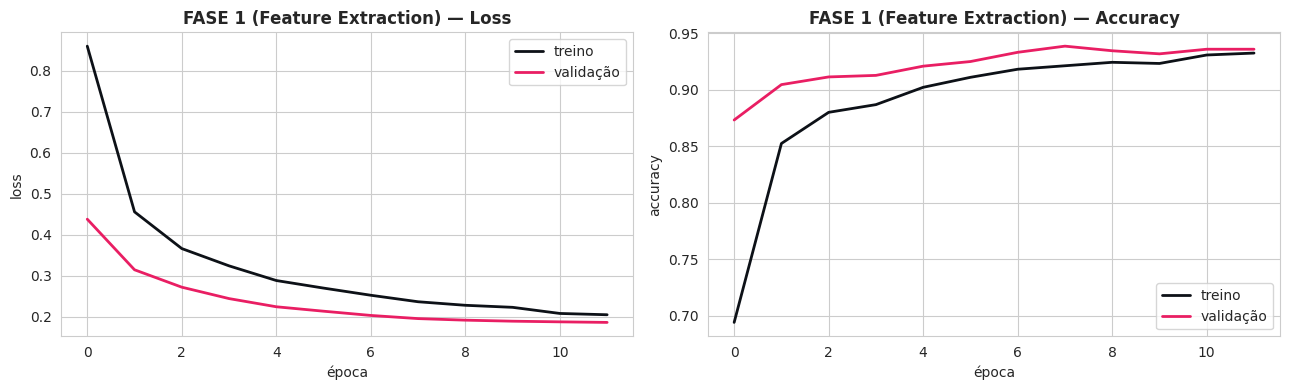


>> Melhor val_accuracy Fase 1: 0.9387
>> Ganho sobre o baseline:   +20.4 pontos percentuais


In [13]:
# --- curvas da Fase 1 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_p1.history['loss'], label='treino', color='#0D1117', lw=2)
axes[0].plot(history_p1.history['val_loss'], label='validação', color='#E91E63', lw=2)
axes[0].set_title('FASE 1 (Feature Extraction) — Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('época'); axes[0].set_ylabel('loss'); axes[0].legend()

axes[1].plot(history_p1.history['accuracy'], label='treino', color='#0D1117', lw=2)
axes[1].plot(history_p1.history['val_accuracy'], label='validação', color='#E91E63', lw=2)
axes[1].set_title('FASE 1 (Feature Extraction) — Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('época'); axes[1].set_ylabel('accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

p1_val_acc = max(history_p1.history['val_accuracy'])
print(f"\n>> Melhor val_accuracy Fase 1: {p1_val_acc:.4f}")
print(f">> Ganho sobre o baseline:   +{(p1_val_acc - baseline_val_acc)*100:.1f} pontos percentuais")


**Leitura típica da Fase 1:** acurácia de validação salta para a faixa de 86-92% — um ganho de 15-25 pontos sobre o baseline, em **menos da metade do tempo de treino**. É exatamente o efeito que esperamos do Transfer Learning quando o domínio é próximo do ImageNet.


---
## Etapa 6 — Fase 2: Fine-Tuning

Ainda dá pra ganhar mais? Sim, com **fine-tuning**: descongelar as **últimas** camadas do backbone para que elas se adaptem ao nosso domínio específico (flores).

### Regras críticas do fine-tuning

1. **Faça só DEPOIS da Fase 1**. Se você descongelar tudo de cara, os gradientes da nova cabeça (ainda aleatória) destroem os pesos pré-treinados.
2. **Learning rate 10-100x menor** que na Fase 1. Aqui vamos de `1e-3` para `1e-5`. Com LR alto, o fine-tuning não ajuda — atrapalha.
3. **Descongele só as últimas camadas** (alto nível). As primeiras aprendem features genéricas (bordas, texturas) que não precisam mudar.


In [14]:
# --- descongelar últimas 30 camadas do backbone ---
base_model.trainable = True

# congelar todas exceto as últimas 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# --- recompilar com LR muito menor ---
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# verificar quantos parâmetros estão treináveis agora
trainable_count = np.sum([np.prod(v.shape) for v in tl_model.trainable_weights])
non_trainable_count = np.sum([np.prod(v.shape) for v in tl_model.non_trainable_weights])
print(f"Parâmetros treináveis agora .... {trainable_count:,}")
print(f"Parâmetros congelados .......... {non_trainable_count:,}")


Parâmetros treináveis agora .... 1,502,565
Parâmetros congelados .......... 2,553,411.0


In [15]:
# --- continuar o treino (Fase 2) ---
early_stop_p2 = EarlyStopping(
    monitor='val_accuracy', patience=4, mode='max',
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2,
    min_lr=1e-7, verbose=1
)

EPOCHS_P1 = len(history_p1.history['loss'])
history_p2 = tl_model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=EPOCHS_P1 + 10,
    initial_epoch=EPOCHS_P1,           # continua a contagem da Fase 1
    callbacks=[early_stop_p2, reduce_lr],
    verbose=1
)


Epoch 13/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step - accuracy: 0.8617 - loss: 0.4309 - val_accuracy: 0.9264 - val_loss: 0.2200 - learning_rate: 1.0000e-05
Epoch 14/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.8685 - loss: 0.4013 - val_accuracy: 0.9223 - val_loss: 0.2394 - learning_rate: 1.0000e-05
Epoch 15/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8874 - loss: 0.3469
Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.8910 - loss: 0.3469 - val_accuracy: 0.9183 - val_loss: 0.2411 - learning_rate: 1.0000e-05
Epoch 16/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.8907 - loss: 0.3408 - val_accuracy: 0.9183 - val_loss: 0.2431 - learning_rate: 5.0000e-06
Epoch 17/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8943 - loss: 0.3245
Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 

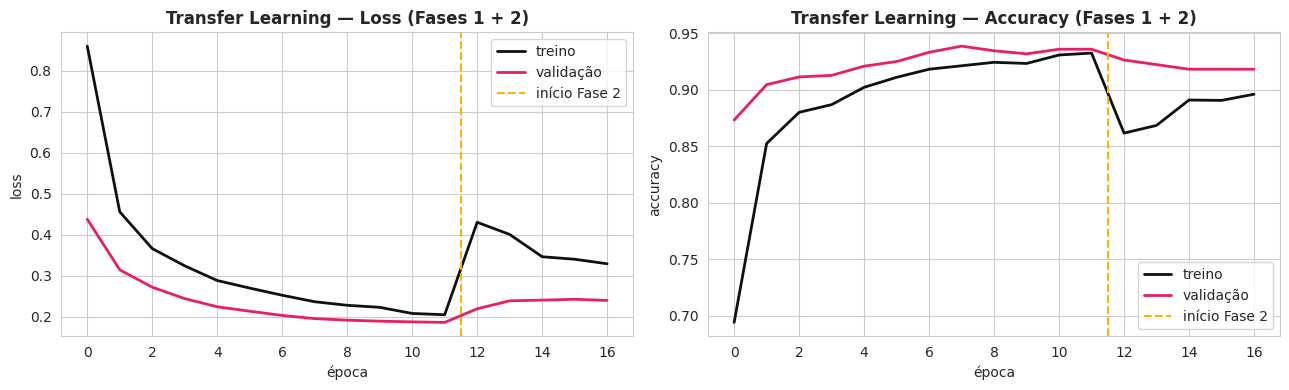


>> Melhor val_accuracy Fase 2: 0.9264
>> Ganho da Fase 2 sobre Fase 1: +-1.2 pontos


In [16]:
# --- curvas combinadas: Fase 1 + Fase 2 ---
acc_combined  = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc_comb  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss_combined = history_p1.history['loss']         + history_p2.history['loss']
val_loss_comb = history_p1.history['val_loss']     + history_p2.history['val_loss']
phase_split   = len(history_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(loss_combined, label='treino', color='#0D1117', lw=2)
axes[0].plot(val_loss_comb, label='validação', color='#E91E63', lw=2)
axes[0].axvline(phase_split - 0.5, color='#FFB300', ls='--', lw=1.5, label='início Fase 2')
axes[0].set_title('Transfer Learning — Loss (Fases 1 + 2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('época'); axes[0].set_ylabel('loss'); axes[0].legend()

axes[1].plot(acc_combined, label='treino', color='#0D1117', lw=2)
axes[1].plot(val_acc_comb, label='validação', color='#E91E63', lw=2)
axes[1].axvline(phase_split - 0.5, color='#FFB300', ls='--', lw=1.5, label='início Fase 2')
axes[1].set_title('Transfer Learning — Accuracy (Fases 1 + 2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('época'); axes[1].set_ylabel('accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

p2_val_acc = max(history_p2.history['val_accuracy'])
print(f"\n>> Melhor val_accuracy Fase 2: {p2_val_acc:.4f}")
print(f">> Ganho da Fase 2 sobre Fase 1: +{(p2_val_acc - p1_val_acc)*100:.1f} pontos")


**Leitura típica da Fase 2:** mais 2-5 pontos de acurácia, geralmente ultrapassando 92%. A linha amarela tracejada marca o ponto onde liberamos as últimas camadas — note como a curva de validação dá outro salto a partir dali.

Se a Fase 2 **não melhora** ou **piora**, é sinal de que:
- O LR está alto demais (tente 1e-6)
- Você descongelou camadas demais
- O dataset é pequeno demais para esse fine-tuning — fique apenas com a Fase 1


---
## Etapa 7 — Comparação dos 3 modelos

Lado a lado: Baseline, Feature Extraction, Fine-Tuning.


In [17]:
# --- tabela comparativa ---
results = pd.DataFrame({
    'Modelo': ['Baseline (do zero)', 'Feature Extraction', 'Fine-Tuning'],
    'Val Accuracy': [baseline_val_acc, p1_val_acc, p2_val_acc],
    'Épocas treinadas': [
        len(history_baseline.history['loss']),
        len(history_p1.history['loss']),
        len(history_p1.history['loss']) + len(history_p2.history['loss']),
    ],
    'Parâmetros treinados': ['~150K (todos)', '~6K (só cabeça)', '~1,2M (cabeça + 30 layers)'],
})
results['Val Accuracy'] = results['Val Accuracy'].apply(lambda x: f"{x:.4f}")
print(results.to_string(index=False))


            Modelo Val Accuracy  Épocas treinadas       Parâmetros treinados
Baseline (do zero)       0.7343                15              ~150K (todos)
Feature Extraction       0.9387                12            ~6K (só cabeça)
       Fine-Tuning       0.9264                17 ~1,2M (cabeça + 30 layers)


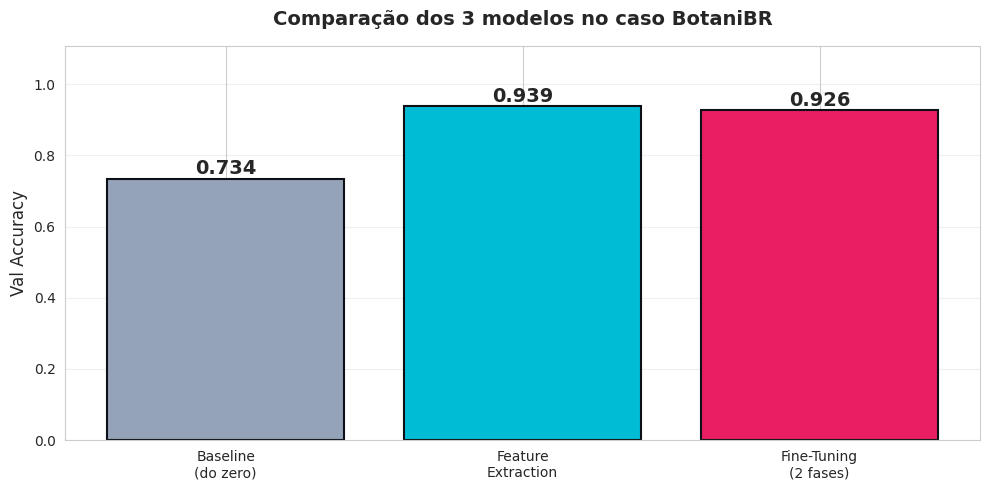

In [18]:
# --- gráfico comparativo ---
fig, ax = plt.subplots(figsize=(10, 5))

modelos = ['Baseline\n(do zero)', 'Feature\nExtraction', 'Fine-Tuning\n(2 fases)']
accs = [baseline_val_acc, p1_val_acc, p2_val_acc]
cores = ['#94A3B8', '#00BCD4', '#E91E63']

bars = ax.bar(modelos, accs, color=cores, edgecolor='#0D1117', linewidth=1.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{acc:.3f}', ha='center', fontsize=14, fontweight='bold')

ax.set_ylim(0, max(accs) * 1.18)
ax.set_ylabel('Val Accuracy', fontsize=12)
ax.set_title('Comparação dos 3 modelos no caso BotaniBR',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


---
## Etapa 8 — Análise de erros do melhor modelo

A acurácia final é uma boa métrica — mas **onde** o modelo erra é igualmente importante. Talvez ele esteja confundindo apenas duas classes parecidas, ou errando consistentemente em fotos com fundo branco. Sem matriz de confusão, não dá pra saber.


In [19]:
# --- coletar predições no conjunto de validação ---
y_true, y_pred = [], []

for images, labels in ds_val_prepared:
    preds = tl_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total de imagens avaliadas: {len(y_true)}")
print(f"Acurácia em validação:      {(y_true == y_pred).mean():.4f}")


Total de imagens avaliadas: 734
Acurácia em validação:      0.9264


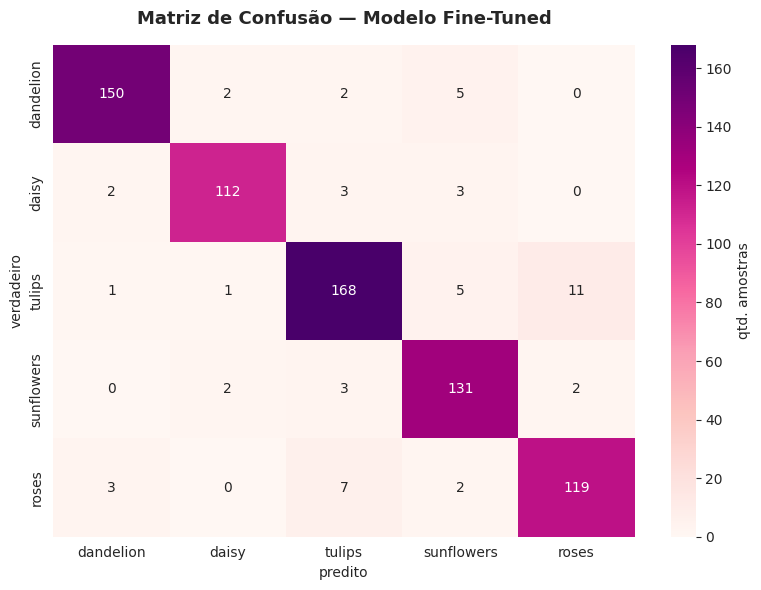

In [20]:
# --- matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'qtd. amostras'}, ax=ax)
ax.set_title('Matriz de Confusão — Modelo Fine-Tuned',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('predito')
ax.set_ylabel('verdadeiro')
plt.tight_layout()
plt.show()


In [21]:
# --- relatório por classe ---
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=3
)
print(report)


              precision    recall  f1-score   support

   dandelion      0.962     0.943     0.952       159
       daisy      0.957     0.933     0.945       120
      tulips      0.918     0.903     0.911       186
  sunflowers      0.897     0.949     0.923       138
       roses      0.902     0.908     0.905       131

    accuracy                          0.926       734
   macro avg      0.927     0.928     0.927       734
weighted avg      0.927     0.926     0.927       734



**Como ler:** olhe os elementos fora da diagonal — esses são os erros. Se uma célula fora da diagonal tem valor alto, o modelo está confundindo essas duas classes especificamente. Em flores, é comum tulip ↔ rose (formas parecidas) ou daisy ↔ dandelion (ambas com pétalas radiais brancas/amarelas).

### Visualizando os erros

Olhar cada caso mal classificado dá insight sobre o que o modelo "vê". Muitas vezes o erro é até **defensável** — fotos com pétalas escondidas, ângulos atípicos, ou a flor cobrindo metade da imagem.


Erros coletados: 12


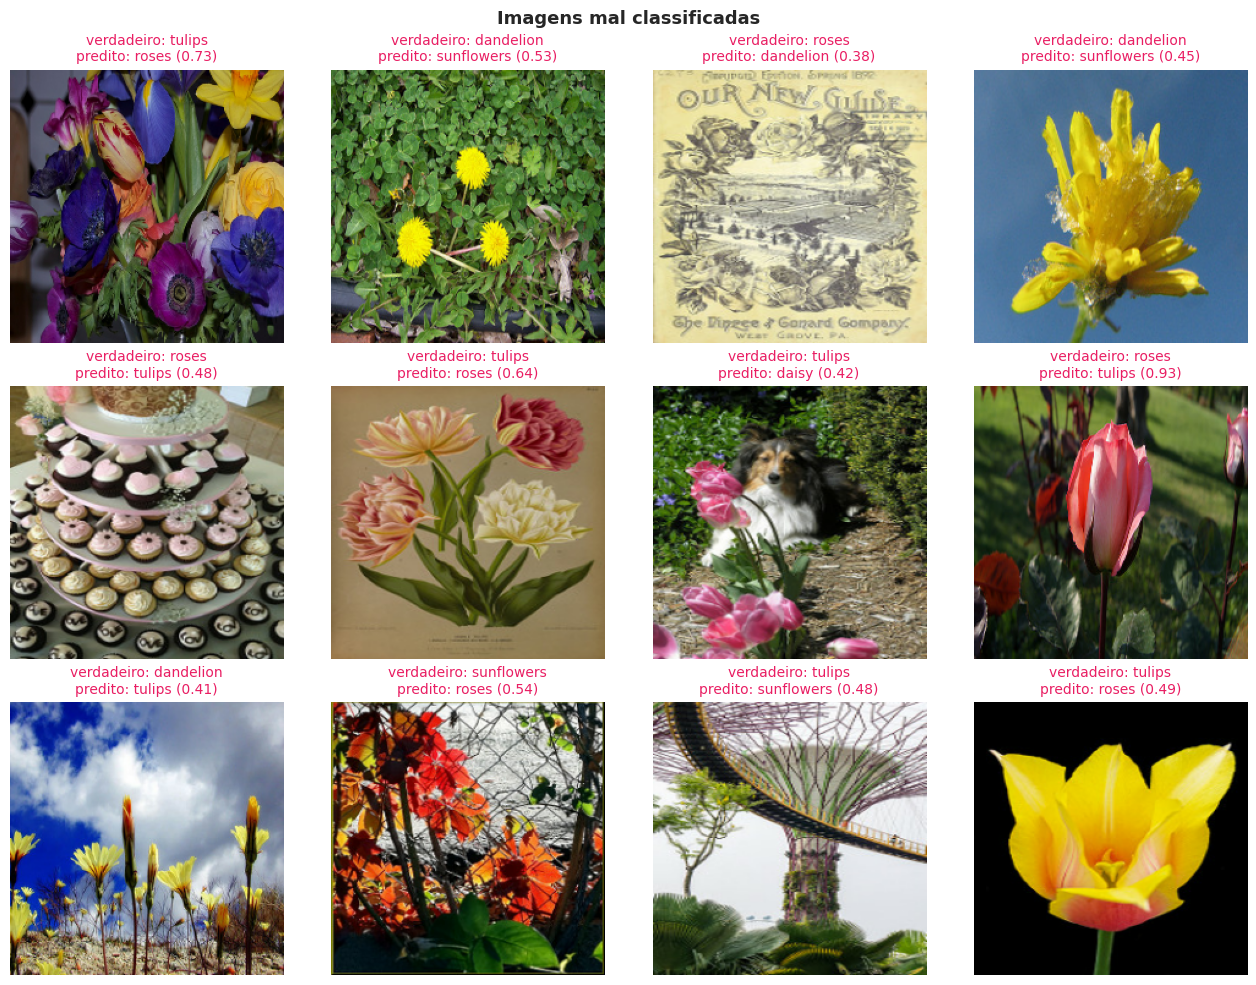

In [22]:
# --- coletar imagens mal classificadas ---
errors = []
batch_idx = 0

for images, labels in ds_val_prepared:
    preds = tl_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    pred_probs = np.max(preds, axis=1)
    for i in range(len(labels)):
        if pred_labels[i] != labels[i].numpy():
            errors.append({
                'image': images[i].numpy().astype('uint8'),
                'true': CLASS_NAMES[labels[i].numpy()],
                'pred': CLASS_NAMES[pred_labels[i]],
                'conf': pred_probs[i],
            })
    batch_idx += 1
    if len(errors) >= 12:
        break

print(f"Erros coletados: {len(errors)}")

# --- visualizar 12 erros ---
n = min(12, len(errors))
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(errors[i]['image'])
        ax.set_title(
            f"verdadeiro: {errors[i]['true']}\npredito: {errors[i]['pred']} ({errors[i]['conf']:.2f})",
            fontsize=10, color='#E91E63'
        )
    ax.axis('off')

plt.suptitle('Imagens mal classificadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Etapa 9 — Inferência em imagens novas

O output que o time da BotaniBR vai consumir em produção: para cada imagem do fornecedor, devolver a **classe predita** e a **confiança** (top-3 probabilidades).


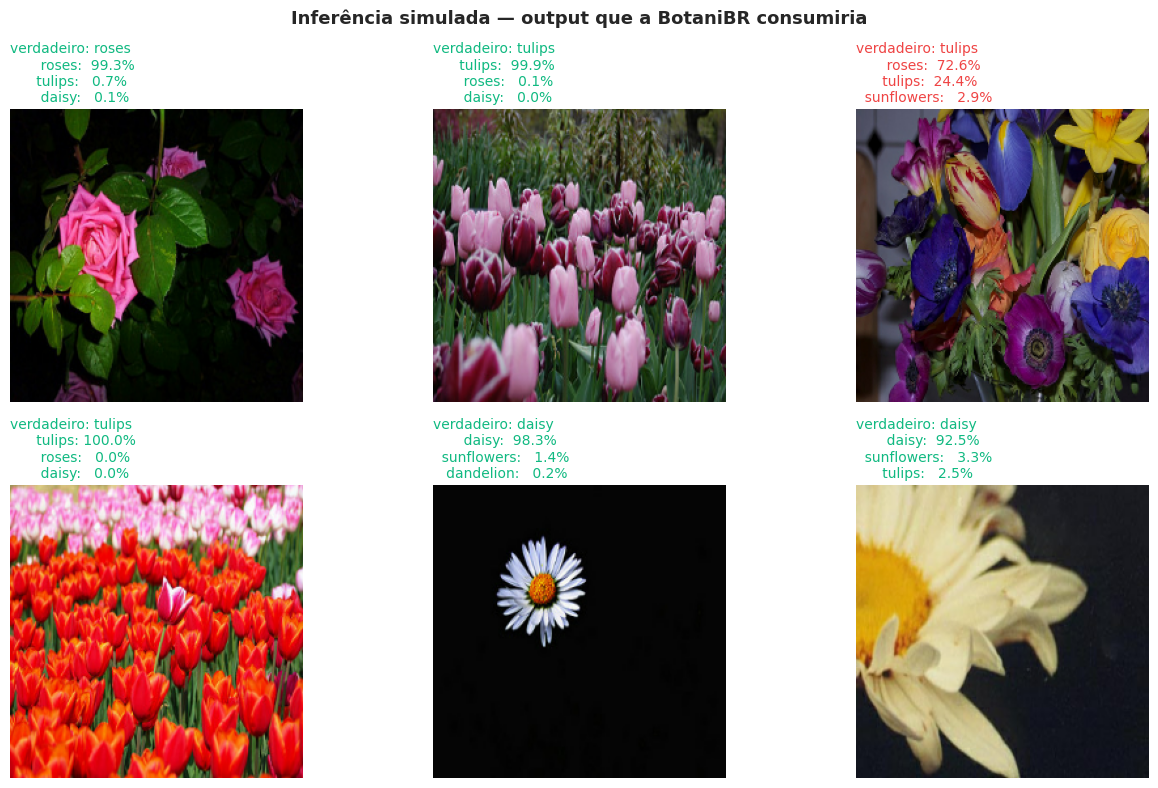

In [23]:
# --- pegar 6 imagens aleatórias da validação para "simular" produção ---
sample_imgs, sample_lbls = [], []
for images, labels in ds_val_prepared.take(1):
    for i in range(6):
        sample_imgs.append(images[i].numpy())
        sample_lbls.append(labels[i].numpy())

# --- predizer ---
batch = np.stack(sample_imgs)
probs = tl_model.predict(batch, verbose=0)

# --- visualizar com top-3 ---
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].astype('uint8')
    ax.imshow(img)
    ax.axis('off')

    true_class = CLASS_NAMES[sample_lbls[i]]
    p = probs[i]
    top3_idx = np.argsort(p)[::-1][:3]
    top3_str = "\n".join(
        f"  {CLASS_NAMES[idx]:>10s}: {p[idx]*100:5.1f}%" for idx in top3_idx
    )

    pred = CLASS_NAMES[top3_idx[0]]
    color = '#10B981' if pred == true_class else '#EF4444'
    ax.set_title(f"verdadeiro: {true_class}\n{top3_str}",
                 fontsize=10, color=color, loc='left')

plt.suptitle('Inferência simulada — output que a BotaniBR consumiria',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Etapa 10 — Recapitulação e próximos passos

### O que rodamos hoje

| Etapa | Modelo | Estratégia |
|---|---|---|
| 1 | CNN simples | Treinada do zero — referência |
| 2 | EfficientNetB0 | Feature Extraction (backbone congelado) |
| 3 | EfficientNetB0 | Fine-Tuning (últimas 30 camadas, LR 100x menor) |

### Os 5 takeaways

1. **Reaproveite quando puder** — treinar do zero deve ser exceção, não regra. Comece sempre do pré-treinado.
2. **Backbone aprende o genérico** — bordas, texturas, formas são universais; funciona até em domínios diferentes do ImageNet.
3. **Duas fases sempre** — Feature Extraction primeiro, Fine-Tuning depois. Nunca o contrário.
4. **Augmentation só no treino** — validação tem que parecer com o mundo real (fotos cruas como na BotaniBR).
5. **Olhe os erros, não só a métrica** — confusion matrix e imagens mal classificadas dizem mais que um único número.

### Quando usar cada estratégia

```
Poucos dados (centenas)  + domínio similar     →  Feature Extraction
Dados moderados (milhares) + similar           →  Feature Extraction + Fine-Tuning
Muitos dados + domínio diferente               →  Fine-Tuning extenso ou treinar do zero
```

### Próximos passos sugeridos para a BotaniBR

- **Mais classes**: expandir das 5 espécies-piloto para o catálogo completo (~30 espécies).
- **Outras backbones**: testar `EfficientNetB3` (mais capacidade) ou `MobileNetV3` (deploy mobile).
- **Class weighting**: quando classes mais raras forem incluídas, ajustar `class_weight` no `.fit()`.
- **Test-Time Augmentation (TTA)**: media de predições sobre versões aumentadas da mesma imagem em produção.
- **Quantização** (TF-Lite) para reduzir o modelo final em ~4x antes de subir em produção.
- **Gradio/FastAPI**: empacotar a inferência como API que o time de operações consome.

---

*FIAP · MBA Data Science & IA · Deep Learning*
